In [ ]:
# Train GSFM
import os
import math
import numpy as np
import pandas as pd
from GSFM import GSFM

data_dir = r"E:\BJTU-Thesis\data\campus_field_train"
ped_only = False

all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))

# ==== GA参数设置 ====
pop_size = 20
generations = 10  # 最大代数，early stop 生效时可能提前结束
mutation_rate = 0.3
mutation_range = 0.1
elite_count = 2

# ==== Early Stopping 参数 ====
n_no_improve = 3
min_delta = 0.02
no_improve_count = 0
prev_best_fitness = float('inf')

# Define parameter bounds for initialization and mutation (as dictionary of param: (min, max))
param_bounds = {
    '''
    'tau': (0.2, 2.0),  # smaller tau allows quicker response
    'ped_ped_strength_repul': (1.0, 20.0),
    'ped_ped_range_repul': (0.3, 2.0),
    'ped_ped_strength_navig': (1.0, 20.0),
    'ped_ped_range_navig': (0.5, 3.0),
    'anisotropy_lambda_repul': (0.1, 1.0),   # 0 = full anisotropy, 1 = isotropic
    'anisotropy_lambda_navig': (0.1, 1.0), 
    'ped_des_speed': (1.0, 2.5),  # typical walking speed range
    'destination_sigma': (0.1, 3.0),
    'des_strength': (1.0, 10.0),
    '''
    'ped_ped_strength_repul': (1.0, 20.0),
    'ped_ped_strength_navig': (1.0, 20.0),
    'des_strength': (1.0, 10.0),
    'ped_veh_strength': (10.0, 50.0),
    'ped_veh_decay': (0.1, 2.0),  # smaller decay = longer-range vehicle repulsion
    'crowd_range_fo': (1.0, 5.0),
    'TTC_threshold': (0.1, 3.0),  # sensitivity to near-collision
    'spd_yield_sigma': (0.0, 1.0),
    'GT_weight': (0.0, 1.0),
    'ped_single_alpha': (0.0, 1.0),
    'ped_group_alpha': (0.0, 1.0),
    'ped_ped_range_repul': (0.3, 2.0),
    'ped_ped_range_navig': (0.5, 3.0),
    'ped_des_speed': (1.0, 2.5),  # typical walking speed range
    'destination_sigma': (0.1, 3.0),
    'anisotropy_lambda_p2v': (0.1, 1.0)
}


# ==== 模型评估函数 ====
def evaluate_params(params, verbose=True):
    total_error = 0.0
    total_count = 0
    model = GSFM(params=params)

    for ped_file, veh_file in scenario_files:
        ped_path = os.path.join(data_dir, ped_file)
        veh_path = os.path.join(data_dir, veh_file) if veh_file else None

        if veh_path and not os.path.exists(veh_path):
            veh_path = None

        try:
            metrics = model.evaluate(ped_path, veh_path)
            total_error += metrics['pos_mean']
            total_count += 1
        except Exception as e:
            print(f"!!!!!!Error evaluating {ped_file} + {veh_file}: {e}")
            continue

    avg_error = total_error / total_count if total_count > 0 else float('inf')

    if verbose:
        print(f"Evaluated: {params}\n-- Avg position error: {avg_error:.4f}\n")

    return avg_error

# ==== 初始化种群 ====
population = []
for _ in range(pop_size):
    indiv = {
        param: round(np.random.uniform(low, high), 1)
        for param, (low, high) in param_bounds.items()
    }
    population.append(indiv)

# ==== GA主循环 ====
best_params = None
best_fitness = float('inf')
fitness_history = []

for gen in range(1, generations + 1):
    print(f"\n=== Generation #{gen}/{generations} Evaluation ===")
    fitness_values = []

    for indiv in population:
        error = evaluate_params(indiv, verbose=True)
        fitness_values.append(error)
        if error < best_fitness:
            best_fitness = error
            best_params = indiv.copy()
    fitness_history.append(best_fitness)
    print(f"Generation {gen}: Best avg error = {best_fitness:.4f}")

    # ==== Selection: Tournament ====
    mating_pool = []
    while len(mating_pool) < pop_size - elite_count:
        candidates_idx = np.random.choice(range(pop_size), size=3, replace=False)
        best_idx = min(candidates_idx, key=lambda idx: fitness_values[idx])
        mating_pool.append(population[best_idx])

    # ==== Elitism ====
    elite_indices = np.argsort(fitness_values)[:elite_count]
    elites = [population[i] for i in elite_indices]

    # ==== Crossover ====
    new_population = []
    if len(mating_pool) % 2 == 1:
        mating_pool = mating_pool[:-1]
    np.random.shuffle(mating_pool)
    for i in range(0, len(mating_pool), 2):
        parent1, parent2 = mating_pool[i], mating_pool[i + 1]
        child1, child2 = {}, {}
        for param in param_bounds.keys():
            if np.random.rand() < 0.5:
                child1[param] = parent1[param]
                child2[param] = parent2[param]
            else:
                child1[param] = parent2[param]
                child2[param] = parent1[param]
        new_population.extend([child1, child2])

    # ==== Mutation ====
    for indiv in new_population:
        for param, (low, high) in param_bounds.items():
            if np.random.rand() < mutation_rate:
                range_width = high - low
                mutation_amt = np.random.uniform(-mutation_range * range_width,
                                                 mutation_range * range_width)
                new_val = indiv[param] + mutation_amt
                new_val = max(min(new_val, high), low)
                indiv[param] = round(new_val, 1)

    # ==== 生成下一代 ====
    population = elites + new_population
    population = population[:pop_size]

    # ==== Early stopping 检查 ====
    improvement = prev_best_fitness - best_fitness
    if improvement < min_delta:
        no_improve_count += 1
        print(f"[Early Stop Monitor] No significant improvement for {no_improve_count} generation(s). Δ = {improvement:.6f}")
    else:
        no_improve_count = 0
        prev_best_fitness = best_fitness

    if no_improve_count >= n_no_improve:
        print(f"\n=== Early stopping: No significant improvement in the last {n_no_improve} generations. ===\n")
        break

# ==== 输出结果 ====
print("Best parameters found:", best_params)
print("Best average position error:", best_fitness)
if no_improve_count >= n_no_improve:
    print("Stopped early due to convergence criteria.")



=== Generation #1/10 Evaluation ===
Evaluated: {"\n    'tau': (0.2, 2.0),  # smaller tau allows quicker response\n    'ped_ped_strength_repul': (1.0, 20.0),\n    'ped_ped_range_repul': (0.3, 2.0),\n    'ped_ped_strength_navig': (1.0, 20.0),\n    'ped_ped_range_navig': (0.5, 3.0),\n    'anisotropy_lambda_repul': (0.1, 1.0),   # 0 = full anisotropy, 1 = isotropic\n    'anisotropy_lambda_navig': (0.1, 1.0), \n    'ped_des_speed': (1.0, 2.5),  # typical walking speed range\n    'destination_sigma': (0.1, 3.0),\n    'des_strength': (1.0, 10.0),\n    ped_ped_strength_repul": 11.8, 'ped_ped_strength_navig': 17.8, 'des_strength': 4.8, 'ped_veh_strength': 33.5, 'ped_veh_decay': 0.3, 'crowd_range_fo': 4.9, 'TTC_threshold': 0.2, 'spd_yield_sigma': 0.7, 'GT_weight': 0.5, 'ped_single_alpha': 0.8, 'ped_group_alpha': 0.4, 'ped_ped_range_repul': 0.9, 'ped_ped_range_navig': 1.6, 'ped_des_speed': 1.7, 'destination_sigma': 2.5, 'anisotropy_lambda_p2v': 0.7}
-- Avg position error: 0.9795

Evaluated: {"\n

In [3]:
# Train the traditional SFM
import os
import math
import numpy as np
import pandas as pd
from SFM import SFM  # 你原有的模型类

# ==== 数据集路径与场景读取 ====
data_dir = r"E:\BJTU-Thesis\data\campus_field_train"
ped_only = False

all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))

# ==== GA参数设置 ====
pop_size = 20
generations = 10  # 最大代数，early stop 生效时可能提前结束
mutation_rate = 0.3
mutation_range = 0.1
elite_count = 2

# ==== Early Stopping 参数 ====
n_no_improve = 3
min_delta = 0.1
no_improve_count = 0
prev_best_fitness = float('inf')

param_bounds = {
    'tau': (0.2, 2.0),  # smaller tau allows quicker response
    'ped_ped_strength_repul': (1.0, 20.0),
    'ped_ped_range_repul': (0.3, 2.0),
    'ped_ped_strength_navig': (1.0, 20.0),
    'ped_ped_range_navig': (0.5, 3.0),
    'ped_des_speed': (1.0, 2.5),  # typical walking speed range
    'destination_sigma': (0.1, 3.0),
    'des_strength': (1.0, 10.0),
    'ped_veh_strength': (10.0, 50.0),
    'ped_veh_decay': (0.1, 2.0),  # smaller decay = longer-range vehicle repulsion
    'anisotropy_lambda_p2v': (0.1, 1.0),
    'ped_single_alpha': (0.0, 1.0)
}

# ==== 模型评估函数 ====
def evaluate_params(params, verbose=True):
    total_error = 0.0
    total_count = 0
    model = SFM(params=params)

    for ped_file, veh_file in scenario_files:
        ped_path = os.path.join(data_dir, ped_file)
        veh_path = os.path.join(data_dir, veh_file) if veh_file else None

        if veh_path and not os.path.exists(veh_path):
            veh_path = None

        try:
            metrics = model.evaluate(ped_path, veh_path)
            total_error += metrics['pos_mean']
            total_count += 1
        except Exception as e:
            print(f"!!!!!!Error evaluating {ped_file} + {veh_file}: {e}")
            continue

    avg_error = total_error / total_count if total_count > 0 else float('inf')

    if verbose:
        print(f"Evaluated: {params}\n-- Avg position error: {avg_error:.4f}\n")

    return avg_error

# ==== 初始化种群 ====
population = []
for _ in range(pop_size):
    indiv = {
        param: round(np.random.uniform(low, high), 1)
        for param, (low, high) in param_bounds.items()
    }
    population.append(indiv)

# ==== GA主循环 ====
best_params = None
best_fitness = float('inf')
fitness_history = []

for gen in range(1, generations + 1):
    print(f"\n=== Generation #{gen}/{generations} Evaluation ===")
    fitness_values = []

    for indiv in population:
        error = evaluate_params(indiv, verbose=True)
        fitness_values.append(error)
        if error < best_fitness:
            best_fitness = error
            best_params = indiv.copy()
    fitness_history.append(best_fitness)
    print(f"Generation {gen}: Best avg error = {best_fitness:.4f}")

    # ==== Selection: Tournament ====
    mating_pool = []
    while len(mating_pool) < pop_size - elite_count:
        candidates_idx = np.random.choice(range(pop_size), size=3, replace=False)
        best_idx = min(candidates_idx, key=lambda idx: fitness_values[idx])
        mating_pool.append(population[best_idx])

    # ==== Elitism ====
    elite_indices = np.argsort(fitness_values)[:elite_count]
    elites = [population[i] for i in elite_indices]

    # ==== Crossover ====
    new_population = []
    if len(mating_pool) % 2 == 1:
        mating_pool = mating_pool[:-1]
    np.random.shuffle(mating_pool)
    for i in range(0, len(mating_pool), 2):
        parent1, parent2 = mating_pool[i], mating_pool[i + 1]
        child1, child2 = {}, {}
        for param in param_bounds.keys():
            if np.random.rand() < 0.5:
                child1[param] = parent1[param]
                child2[param] = parent2[param]
            else:
                child1[param] = parent2[param]
                child2[param] = parent1[param]
        new_population.extend([child1, child2])

    # ==== Mutation ====
    for indiv in new_population:
        for param, (low, high) in param_bounds.items():
            if np.random.rand() < mutation_rate:
                range_width = high - low
                mutation_amt = np.random.uniform(-mutation_range * range_width,
                                                 mutation_range * range_width)
                new_val = indiv[param] + mutation_amt
                new_val = max(min(new_val, high), low)
                indiv[param] = round(new_val, 1)

    # ==== 生成下一代 ====
    population = elites + new_population
    population = population[:pop_size]

    # ==== Early stopping 检查 ====
    improvement = prev_best_fitness - best_fitness
    if improvement < min_delta:
        no_improve_count += 1
        print(f"[Early Stop Monitor] No significant improvement for {no_improve_count} generation(s). Δ = {improvement:.6f}")
    else:
        no_improve_count = 0
        prev_best_fitness = best_fitness

    if no_improve_count >= n_no_improve:
        print(f"\n=== Early stopping: No significant improvement in the last {n_no_improve} generations. ===\n")
        break

# ==== 输出结果 ====
print("Best parameters found:", best_params)
print("Best average position error:", best_fitness)
if no_improve_count >= n_no_improve:
    print("Stopped early due to convergence criteria.")



=== Generation #1/10 Evaluation ===
Evaluated: {'tau': 0.8, 'ped_ped_strength_repul': 1.8, 'ped_ped_range_repul': 1.6, 'ped_ped_strength_navig': 6.1, 'ped_ped_range_navig': 2.5, 'ped_des_speed': 1.6, 'destination_sigma': 2.3, 'des_strength': 2.6, 'ped_veh_strength': 23.2, 'ped_veh_decay': 1.3, 'anisotropy_lambda_p2v': 0.4, 'ped_single_alpha': 0.0}
-- Avg position error: 0.9352

Evaluated: {'tau': 1.5, 'ped_ped_strength_repul': 6.6, 'ped_ped_range_repul': 1.7, 'ped_ped_strength_navig': 2.5, 'ped_ped_range_navig': 1.5, 'ped_des_speed': 2.4, 'destination_sigma': 0.9, 'des_strength': 2.5, 'ped_veh_strength': 40.4, 'ped_veh_decay': 0.5, 'anisotropy_lambda_p2v': 0.1, 'ped_single_alpha': 0.5}
-- Avg position error: 0.9555

Evaluated: {'tau': 1.0, 'ped_ped_strength_repul': 12.5, 'ped_ped_range_repul': 0.8, 'ped_ped_strength_navig': 8.4, 'ped_ped_range_navig': 2.5, 'ped_des_speed': 2.2, 'destination_sigma': 1.3, 'des_strength': 10.0, 'ped_veh_strength': 19.3, 'ped_veh_decay': 0.5, 'anisotropy_

In [3]:
import datetime
import matplotlib.pyplot as plt

figure_dir = r"E:\BJTU-Thesis\figures"
os.makedirs(figure_dir, exist_ok=True)

# 设置图像文件名，包含模型名称和时间戳
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
fig_name = f"GA_ErrorDecline_PosMean_{pop_size}pop_{generations}gen_{timestamp}.png"
fig_path = os.path.join(figure_dir, fig_name)

# 绘图与保存
plt.figure(figsize=(8, 5))
plt.plot(range(1, generations + 1), fitness_history, marker='o', color='blue')
plt.title('Best Average Position Error over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Avg Position Error in meter')
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)


NameError: name 'pop_size' is not defined

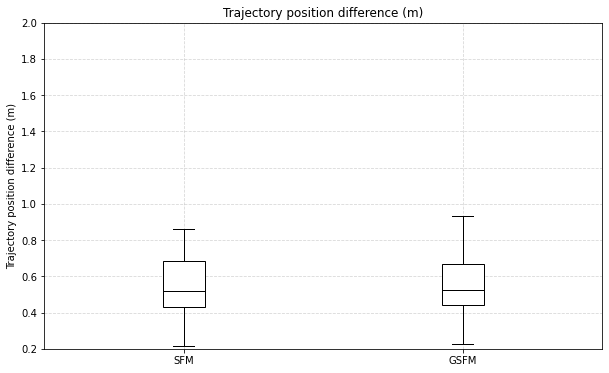

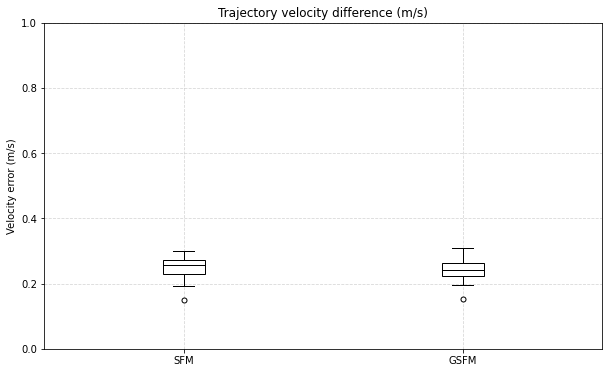

=== Trajectory Prediction Error Statistics ===

SFM - Position Error (m):
  Mean = 0.5479
  Std  = 0.2138

SFM - Velocity Error (m/s):
  Mean = 0.2444
  Std  = 0.0471

GSFM - Position Error (m):
  Mean = 0.5436
  Std  = 0.2101

GSFM - Velocity Error (m/s):
  Mean = 0.2393
  Std  = 0.0454



In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from GSFM import GSFM
from SFM import SFM

# 配置路径与模型参数
data_dir = r"E:\BJTU-Thesis\data\p2p_controlled_test"
gsfm_model = GSFM(params={'tau': 1.4527075700577314, 'ped_ped_strength_repul': 6.3, 'ped_ped_range_repul': 0.7,
                           'ped_ped_strength_navig': 4.450870717348003, 'ped_ped_range_navig': 1.3832453251625427, 
                           'anisotropy_lambda_repul': 0.3468034503968284, 'anisotropy_lambda_navig': 1.0, 'ped_des_speed': 1.4430210243050785,
                             'destination_sigma': 1.6283902901406893, 'des_strength': 3.1, 'ped_single_alpha': 0.5, 'ped_group_alpha': 0.9})
sfm_model = SFM(params= {'tau': 0.3, 'ped_ped_strength_repul': 18.8, 'ped_ped_range_repul': 1.3, 'ped_ped_strength_navig': 1.7, 
                         'ped_ped_range_navig': 2.4, 'anisotropy_lambda_repul': 0.7, 'anisotropy_lambda_navig': 0.5, 'ped_des_speed': 1.4, 
                         'destination_sigma': 1.2, 'des_strength': 9.9, 'ped_single_alpha': 0.6})

# 搜集所有场景文件
all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_dict = {}
for f in all_files:
    key = f.split("_traj_")[0]
    scenario_dict.setdefault(key, {})
    if "_ped_" in f:
        scenario_dict[key]['ped'] = f
    elif "_veh_" in f:
        scenario_dict[key]['veh'] = f
scenario_files = [(v['ped'], v.get('veh')) for v in scenario_dict.values() if 'ped' in v]

# 记录每个模型的 pos_mean
gsfm_pos_errors = []
sfm_pos_errors = []
gsfm_vel_errors = []
sfm_vel_errors = []
scene_names = []

for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    try:
        gsfm_metrics = gsfm_model.evaluate(ped_path, veh_path)
        sfm_metrics = sfm_model.evaluate(ped_path, veh_path)

        gsfm_pos_errors.append(gsfm_metrics['pos_mean'])
        sfm_pos_errors.append(sfm_metrics['pos_mean'])
        gsfm_vel_errors.append(gsfm_metrics['vel_mean'])
        sfm_vel_errors.append(sfm_metrics['vel_mean'])
        scene_names.append(ped_file.split("_traj_")[0])
    except Exception as e:
        print(f"Error in {ped_file}: {e}")

save_dir = r"E:\BJTU-Thesis\figures"
os.makedirs(save_dir, exist_ok=True)

# Position Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_pos_errors, gsfm_pos_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.2, 2.0)
plt.ylabel("Trajectory position difference (m)")
plt.title("Trajectory position difference (m) in P2P controlled")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "CITR_P2P_pos_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

# Velocity Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_vel_errors, gsfm_vel_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.0, 1.0)  # 速度误差合理范围（可调整）
plt.ylabel("Velocity error (m/s)")
plt.title("Trajectory velocity difference (m/s) in P2P controlled")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "CITR_P2P_vel_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

plt.show()

# 输出均值、标准差
def print_stats(name, data):
    data = np.array(data)
    print(f"{name}:\n  Mean = {data.mean():.4f}\n  Std  = {data.std():.4f}\n")

print("=== Trajectory Prediction Error Statistics ===\n")

# --- SFM ---
print_stats("SFM - Position Error (m)", sfm_pos_errors)
print_stats("SFM - Velocity Error (m/s)", sfm_vel_errors)

# --- GSFM ---
print_stats("GSFM - Position Error (m)", gsfm_pos_errors)
print_stats("GSFM - Velocity Error (m/s)", gsfm_vel_errors)


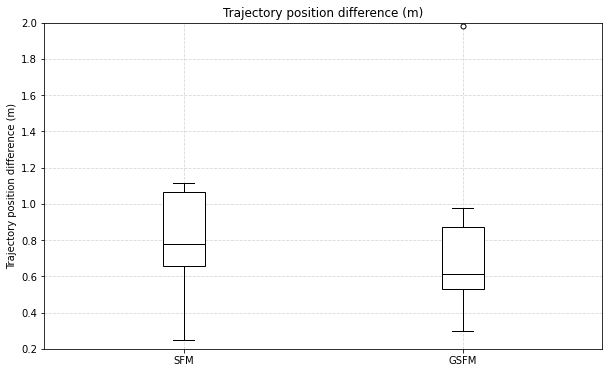

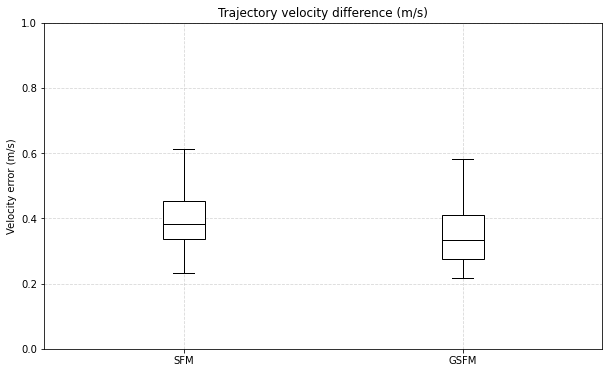

=== Trajectory Prediction Error Statistics ===

SFM - Position Error (m):
  Mean = 0.9100
  Std  = 0.5089

SFM - Velocity Error (m/s):
  Mean = 0.4008
  Std  = 0.1208

GSFM - Position Error (m):
  Mean = 0.7900
  Std  = 0.4908

GSFM - Velocity Error (m/s):
  Mean = 0.3620
  Std  = 0.1205



In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from GSFM import GSFM
from SFM import SFM

# 配置路径与模型参数
data_dir = r"E:\BJTU-Thesis\data\v2p_controlled_test"
gsfm_model = GSFM(params={'tau': 1.6310552657659854, 'ped_ped_range_repul': 2.0, 'ped_ped_range_navig': 0.7918523756812202, 'anisotropy_lambda_repul': 0.1, 'anisotropy_lambda_navig': 0.27685839134203316, 'ped_single_alpha': 0.7209417036239556, 'ped_group_alpha': 0.6302081987206191, 'ped_veh_strength': 32.51783331184852, 'ped_veh_decay': 0.31611223333999283, 'anisotropy_lambda_p2v': 0.5958364800475716, 'crowd_range_fo': 2.6863040699009706, 'crowd_anisotropy_fo': 120.0, 'TTC_threshold': 2.6055574142024036, 'spd_yield_sigma': 0.6825230442430887, 'yield_speed': 0.5687844485695834, 'GT_weight': 1.0})
sfm_model = SFM(params={'tau': 0.7, 'ped_ped_range_repul': 0.8, 'ped_ped_range_navig': 0.8, 'anisotropy_lambda_repul': 0.8, 'anisotropy_lambda_navig': 0.9, 'ped_single_alpha': 0.5, 'ped_veh_strength': 33.5, 'ped_veh_decay': 0.4, 'anisotropy_lambda_p2v': 0.3})

all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_dict = {}
for f in all_files:
    key = f.split("_traj_")[0]
    scenario_dict.setdefault(key, {})
    if "_ped_" in f:
        scenario_dict[key]['ped'] = f
    elif "_veh_" in f:
        scenario_dict[key]['veh'] = f
scenario_files = [(v['ped'], v.get('veh')) for v in scenario_dict.values() if 'ped' in v]

# 记录每个模型的 pos_mean
gsfm_pos_errors = []
sfm_pos_errors = []
gsfm_vel_errors = []
sfm_vel_errors = []
scene_names = []

for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    try:
        gsfm_metrics = gsfm_model.evaluate(ped_path, veh_path)
        sfm_metrics = sfm_model.evaluate(ped_path, veh_path)

        gsfm_pos_errors.append(gsfm_metrics['pos_mean'])
        sfm_pos_errors.append(sfm_metrics['pos_mean'])
        gsfm_vel_errors.append(gsfm_metrics['vel_mean'])
        sfm_vel_errors.append(sfm_metrics['vel_mean'])
        scene_names.append(ped_file.split("_traj_")[0])
    except Exception as e:
        print(f"Error in {ped_file}: {e}")

save_dir = r"E:\BJTU-Thesis\figures"
os.makedirs(save_dir, exist_ok=True)

# Position Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_pos_errors, gsfm_pos_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.2, 2.0)
plt.ylabel("Trajectory position difference (m)")
plt.title("Trajectory position difference (m) in P2V controlled")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "CITR_p2V_pos_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

# Velocity Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_vel_errors, gsfm_vel_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.0, 1.0)  # 速度误差合理范围（可调整）
plt.ylabel("Velocity error (m/s)")
plt.title("Trajectory velocity difference (m/s) in P2V controlled")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "CITR_P2V_vel_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

plt.show()

# 输出均值、标准差
def print_stats(name, data):
    data = np.array(data)
    print(f"{name}:\n  Mean = {data.mean():.4f}\n  Std  = {data.std():.4f}\n")

print("=== Trajectory Prediction Error Statistics ===\n")

# --- SFM ---
print_stats("SFM - Position Error (m)", sfm_pos_errors)
print_stats("SFM - Velocity Error (m/s)", sfm_vel_errors)

# --- GSFM ---
print_stats("GSFM - Position Error (m)", gsfm_pos_errors)
print_stats("GSFM - Velocity Error (m/s)", gsfm_vel_errors)

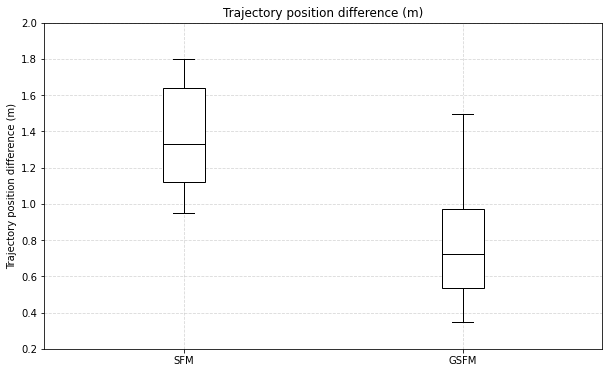

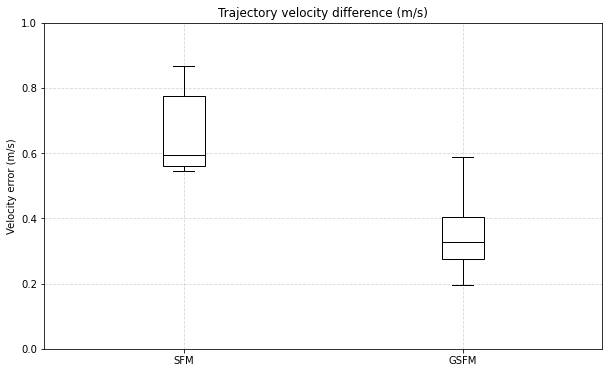

=== Trajectory Prediction Error Statistics ===

SFM - Position Error (m):
  Mean = 1.3669
  Std  = 0.3131

SFM - Velocity Error (m/s):
  Mean = 0.6646
  Std  = 0.1332

GSFM - Position Error (m):
  Mean = 0.8029
  Std  = 0.3801

GSFM - Velocity Error (m/s):
  Mean = 0.3544
  Std  = 0.1254



In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from GSFM import GSFM
from SFM import SFM

# 配置路径与模型参数
data_dir = r"E:\BJTU-Thesis\data\campus_field_test"
gsfm_model = GSFM(params= { 'ped_ped_strength_repul': 10.0, 'ped_ped_strength_navig': 4.2, 'des_strength': 6.9, 'ped_veh_strength': 44.2, 'ped_veh_decay': 0.2, 'crowd_range_fo': 2.1, 'TTC_threshold': 1.8, 'spd_yield_sigma': 0.3, 'GT_weight': 0.2, 'ped_single_alpha': 1.0, 'ped_group_alpha': 0.5, 'ped_ped_range_repul': 1.0, 'ped_ped_range_navig': 0.5, 'ped_des_speed': 1.8, 'destination_sigma': 1.6, 'anisotropy_lambda_p2v': 0.2})
sfm_model = SFM(params=gsfm_model.params)

all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_dict = {}
for f in all_files:
    key = f.split("_traj_")[0]
    scenario_dict.setdefault(key, {})
    if "_ped_" in f:
        scenario_dict[key]['ped'] = f
    elif "_veh_" in f:
        scenario_dict[key]['veh'] = f
scenario_files = [(v['ped'], v.get('veh')) for v in scenario_dict.values() if 'ped' in v]

# 记录每个模型的 pos_mean
gsfm_pos_errors = []
sfm_pos_errors = []
gsfm_vel_errors = []
sfm_vel_errors = []
scene_names = []

for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    try:
        gsfm_metrics = gsfm_model.evaluate(ped_path, veh_path)
        sfm_metrics = sfm_model.evaluate(ped_path, veh_path)

        gsfm_pos_errors.append(gsfm_metrics['pos_mean'])
        sfm_pos_errors.append(sfm_metrics['pos_mean'])
        gsfm_vel_errors.append(gsfm_metrics['vel_mean'])
        sfm_vel_errors.append(sfm_metrics['vel_mean'])
        scene_names.append(ped_file.split("_traj_")[0])
    except Exception as e:
        print(f"Error in {ped_file}: {e}")

save_dir = r"E:\BJTU-Thesis\figures"
os.makedirs(save_dir, exist_ok=True)

# Position Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_pos_errors, gsfm_pos_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.2, 2.0)
plt.ylabel("Trajectory position difference (m)")
plt.title("Trajectory position difference (m)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "DUT_pos_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

# Velocity Error 箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(
    [sfm_vel_errors, gsfm_vel_errors],
    labels=['SFM', 'GSFM'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),
    capprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5),
    medianprops=dict(color='black')
)
plt.ylim(0.0, 1.0)  # 速度误差合理范围（可调整）
plt.ylabel("Velocity error (m/s)")
plt.title("Trajectory velocity difference (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "DUT_vel_mean_sfm_vs_gsfm.png"), bbox_inches='tight', dpi=300)

plt.show()

# 输出均值、标准差
def print_stats(name, data):
    data = np.array(data)
    print(f"{name}:\n  Mean = {data.mean():.4f}\n  Std  = {data.std():.4f}\n")

print("=== Trajectory Prediction Error Statistics ===\n")

# --- SFM ---
print_stats("SFM - Position Error (m)", sfm_pos_errors)
print_stats("SFM - Velocity Error (m/s)", sfm_vel_errors)

# --- GSFM ---
print_stats("GSFM - Position Error (m)", gsfm_pos_errors)
print_stats("GSFM - Velocity Error (m/s)", gsfm_vel_errors)

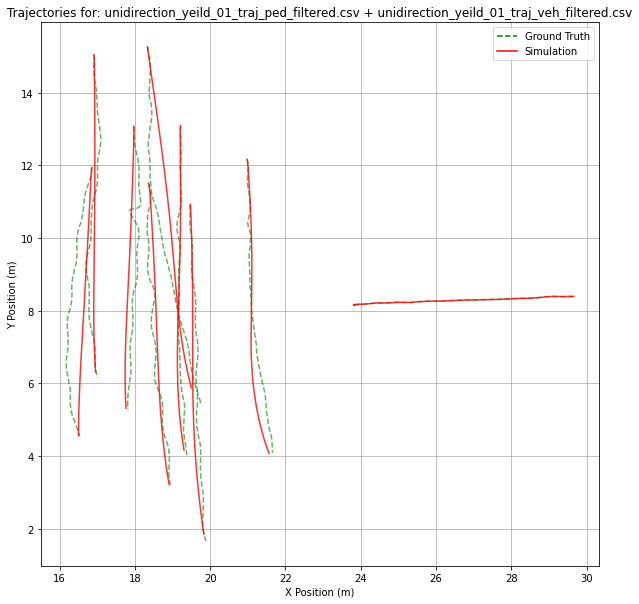

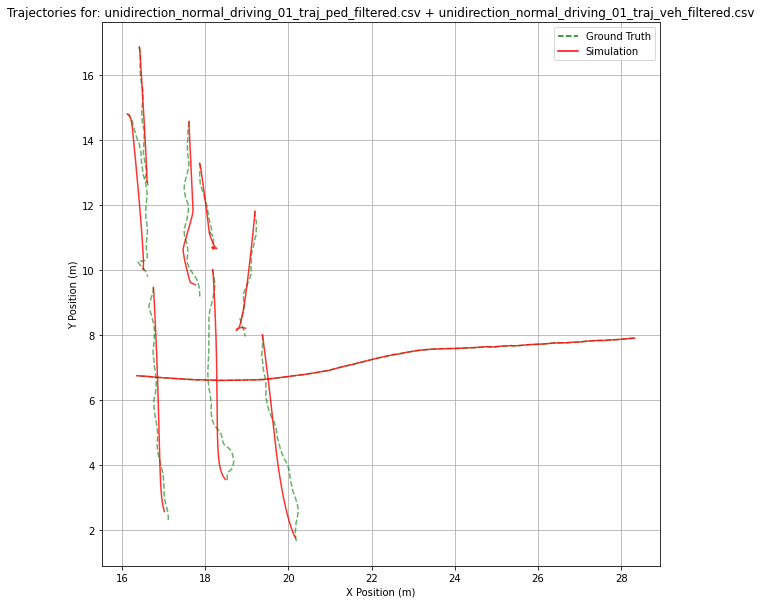

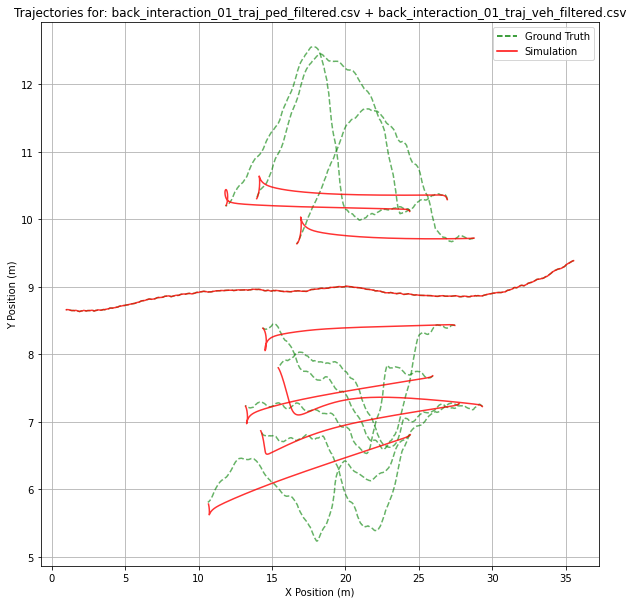

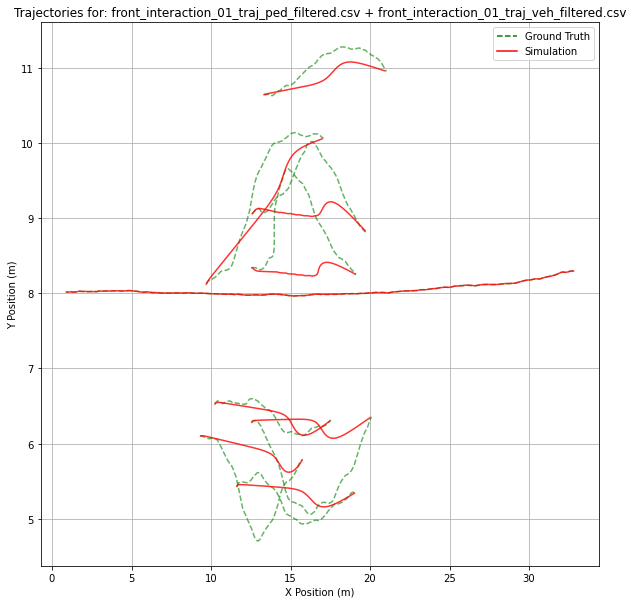

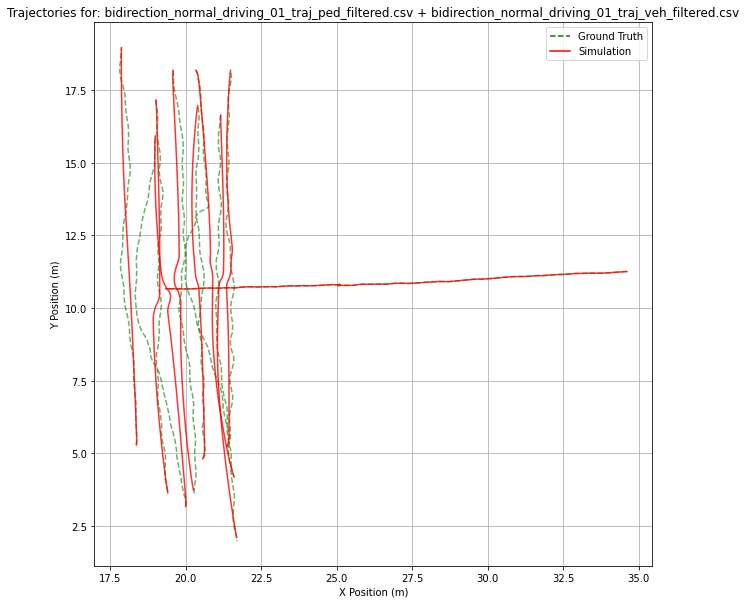

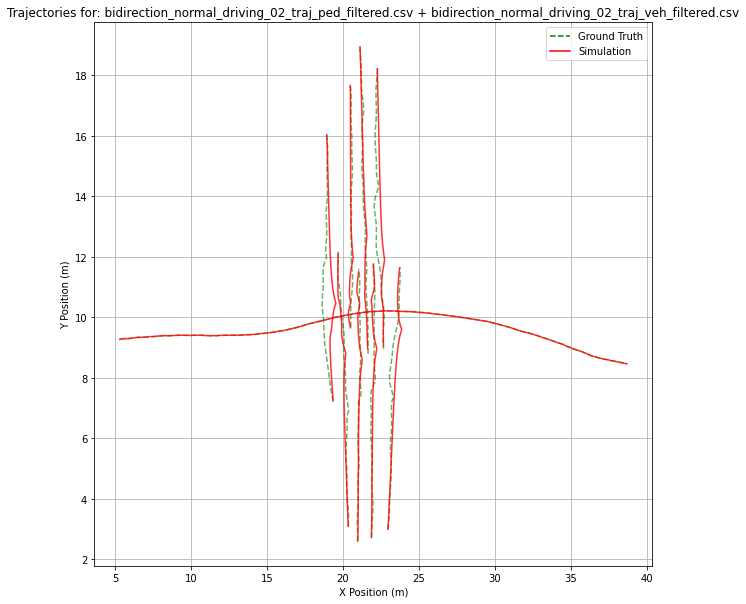

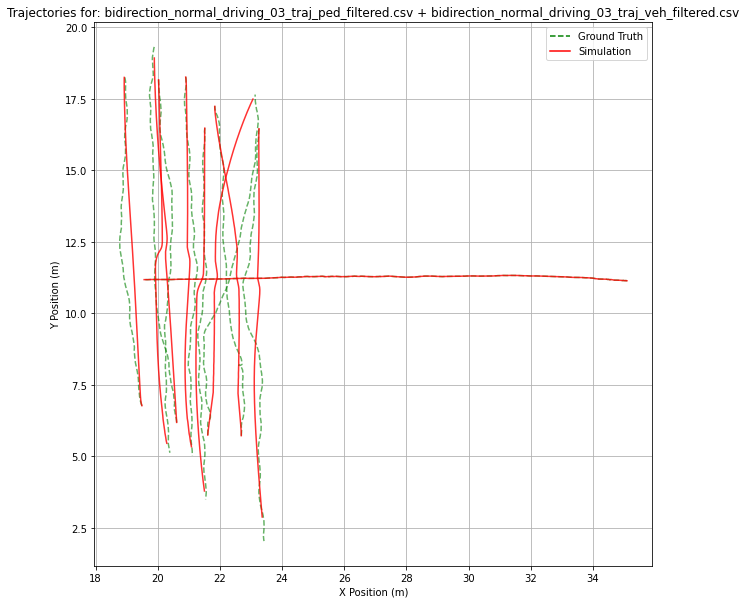

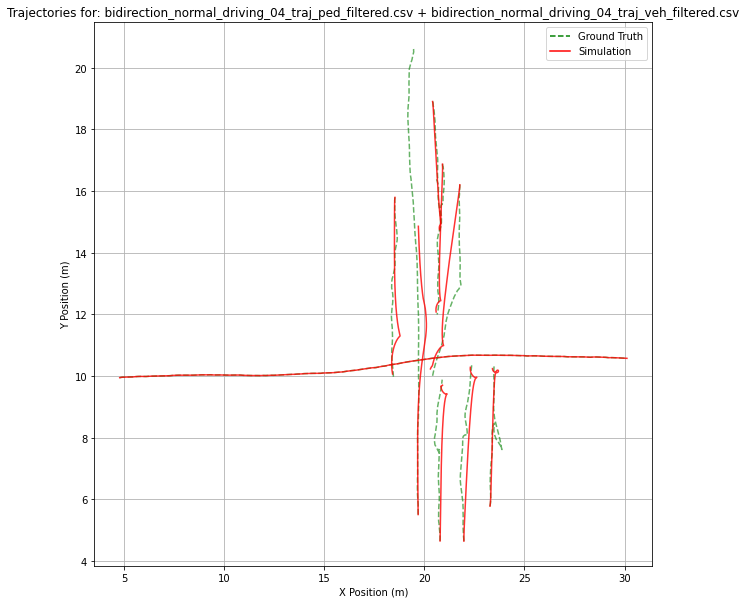

In [2]:
#轨迹绘制 v2p controlled
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from GSFM65 import GSFM
from SFM import SFM

# 配置路径和模型
data_dir = r"E:\BJTU-Thesis\data\v2p_controlled_test"
model = SFM(params= {'tau': 0.7, 'ped_ped_range_repul': 0.8, 'ped_ped_range_navig': 0.8, 'anisotropy_lambda_repul': 0.8, 'anisotropy_lambda_navig': 0.9, 'ped_single_alpha': 0.5, 'ped_veh_strength': 33.5, 'ped_veh_decay': 0.4, 'anisotropy_lambda_p2v': 0.3})
#model = GSFM(params= {'tau': 1.6310552657659854, 'ped_ped_range_repul': 2.0, 'ped_ped_range_navig': 0.7918523756812202, 'anisotropy_lambda_repul': 0.1, 'anisotropy_lambda_navig': 0.27685839134203316, 'ped_single_alpha': 0.7209417036239556, 'ped_group_alpha': 0.6302081987206191, 'ped_veh_strength': 32.51783331184852, 'ped_veh_decay': 0.31611223333999283, 'anisotropy_lambda_p2v': 0.5958364800475716, 'crowd_range_fo': 2.6863040699009706, 'crowd_anisotropy_fo': 120.0, 'TTC_threshold': 2.6055574142024036, 'spd_yield_sigma': 0.6825230442430887, 'yield_speed': 0.5687844485695834, 'GT_weight': 1.0})
all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []
ped_only = False

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))


# 遍历每一个场景文件对并绘图
for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    
    try:
        ped_truth, veh_truth = model.load_data(ped_path, veh_path)
        ped_smlt, veh_smlt = model.simulate(ped_path, veh_path)
    except Exception as e:
        print(f"Error in {ped_file} + {veh_file}: {e}")
        continue

    plt.figure(figsize=(10, 10))

    # 真实轨迹 (绿色虚线)
    for _, grp in ped_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)
    for _, grp in veh_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)

    # 模拟轨迹 (红色实线)
    for traj in ped_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)
    for traj in veh_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)

    # 图示信息
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'Trajectories for: {ped_file} + {veh_file}')
    plt.legend(handles=[
        Line2D([0], [0], color='green', linestyle='--', label='Ground Truth'),
        Line2D([0], [0], color='red',   linestyle='-',  label='Simulation')
    ])
    plt.grid(True)
    plt.show()


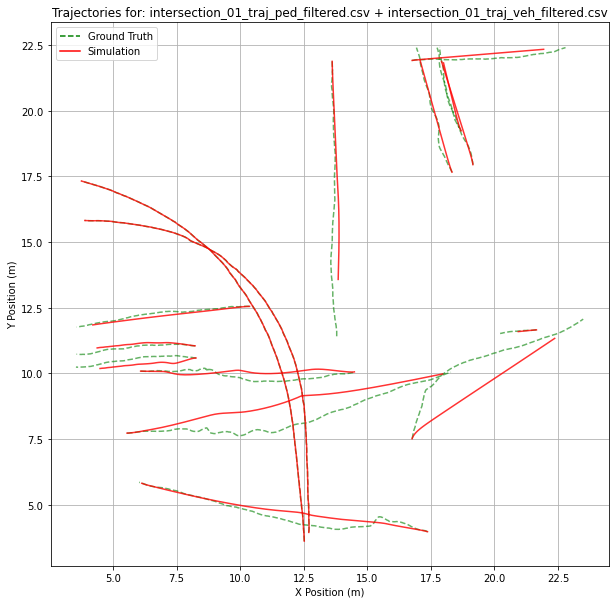

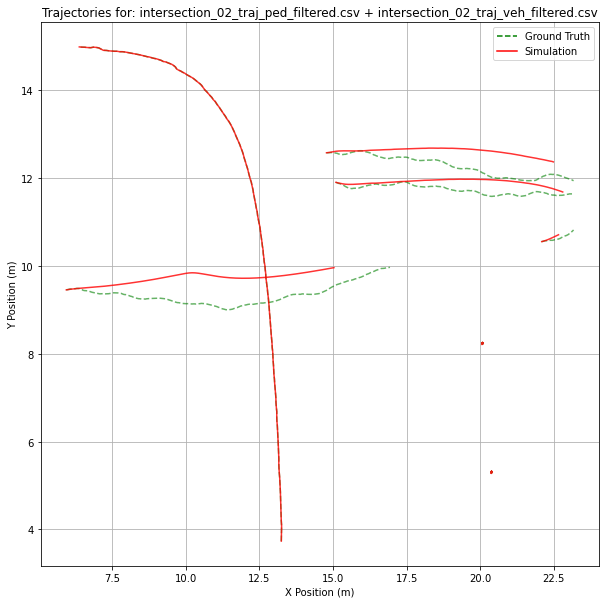

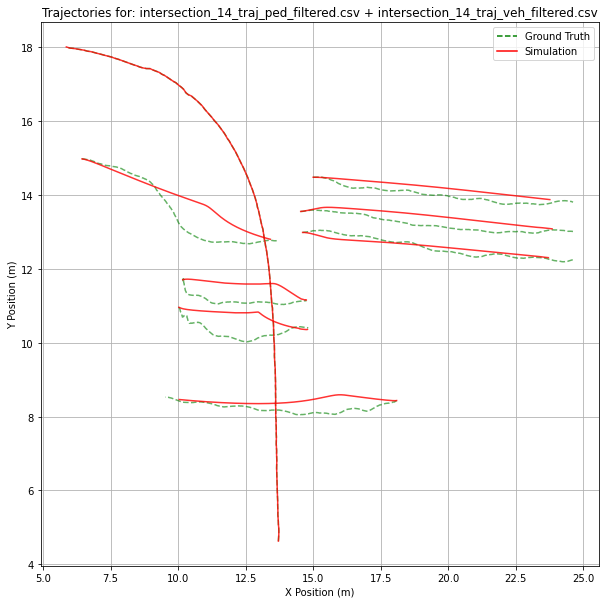

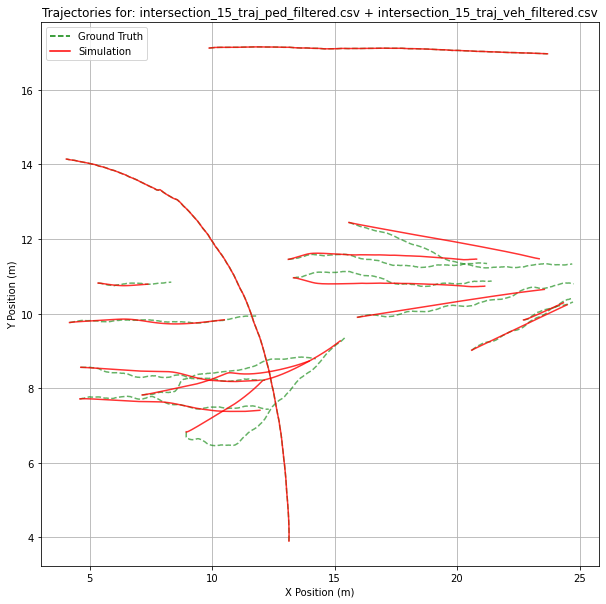

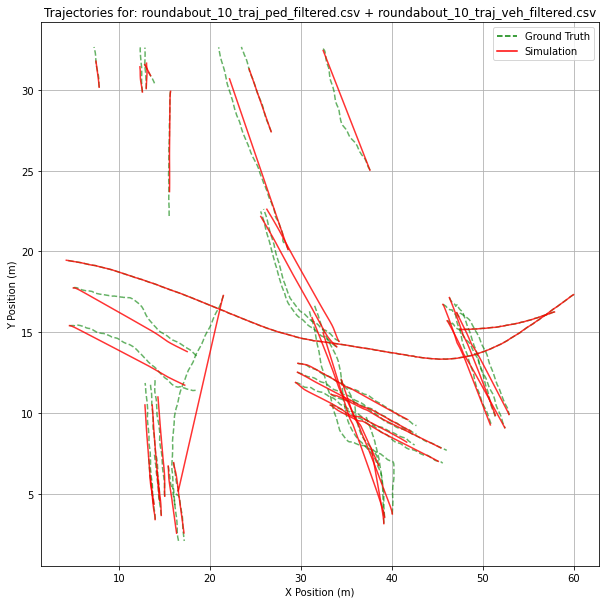

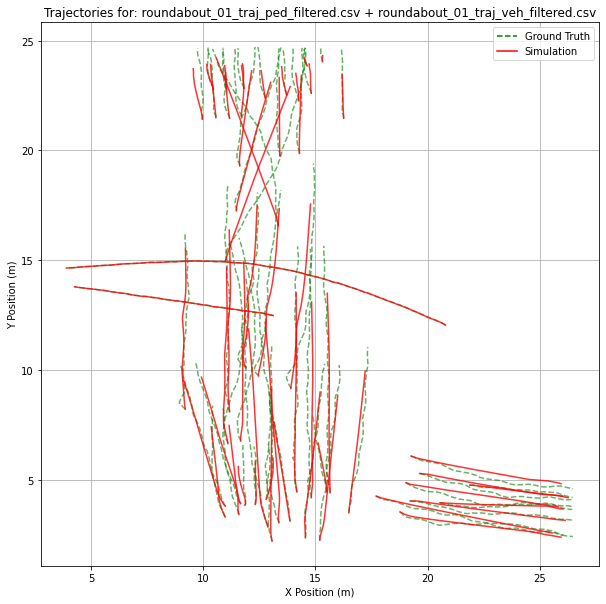

In [1]:
#轨迹绘制 campus
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from GSFM import GSFM
from SFM import SFM

# 配置路径和模型
data_dir = r"E:\BJTU-Thesis\data\campus_field_test"
model = SFM(params= {'tau': 1.7, 'ped_ped_strength_repul': 16.3, 'ped_ped_range_repul': 0.8, 'ped_ped_strength_navig': 13.9, 'ped_ped_range_navig': 0.7, 'ped_des_speed': 1.8, 'destination_sigma': 1.8, 'des_strength': 6.3, 'ped_veh_strength': 14.4, 'ped_veh_decay': 0.3, 'anisotropy_lambda_p2v': 0.9, 'ped_single_alpha': 0.7})

all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []
ped_only = False

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))


# 遍历每一个场景文件对并绘图
for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    
    try:
        ped_truth, veh_truth = model.load_data(ped_path, veh_path)
        ped_smlt, veh_smlt = model.simulate(ped_path, veh_path)
    except Exception as e:
        print(f"Error in {ped_file} + {veh_file}: {e}")
        continue

    plt.figure(figsize=(10, 10))

    # 真实轨迹 (绿色虚线)
    for _, grp in ped_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)
    for _, grp in veh_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)

    # 模拟轨迹 (红色实线)
    for traj in ped_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)
    for traj in veh_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)

    # 图示信息
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'Trajectories for: {ped_file} + {veh_file}')
    plt.legend(handles=[
        Line2D([0], [0], color='green', linestyle='--', label='Ground Truth'),
        Line2D([0], [0], color='red',   linestyle='-',  label='Simulation')
    ])
    plt.grid(True)
    plt.show()


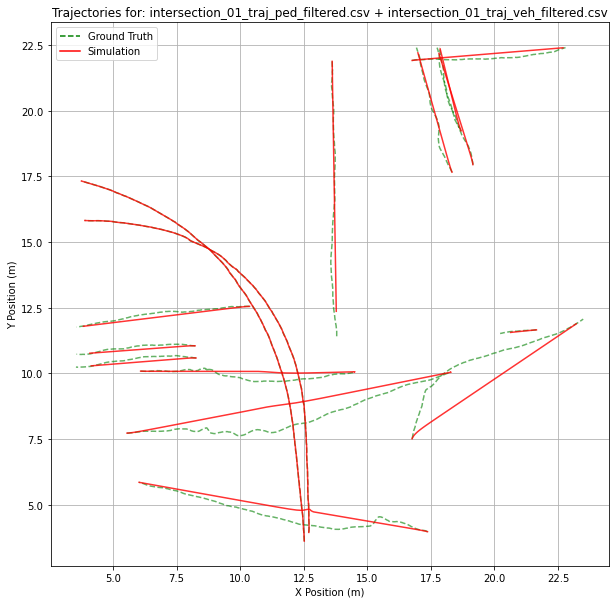

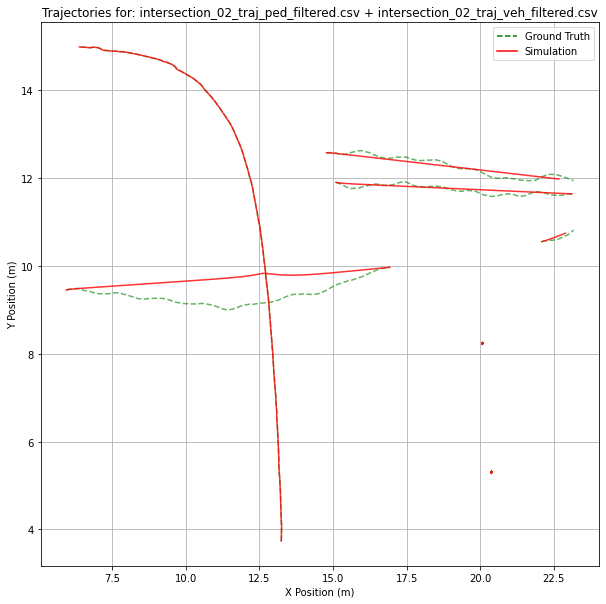

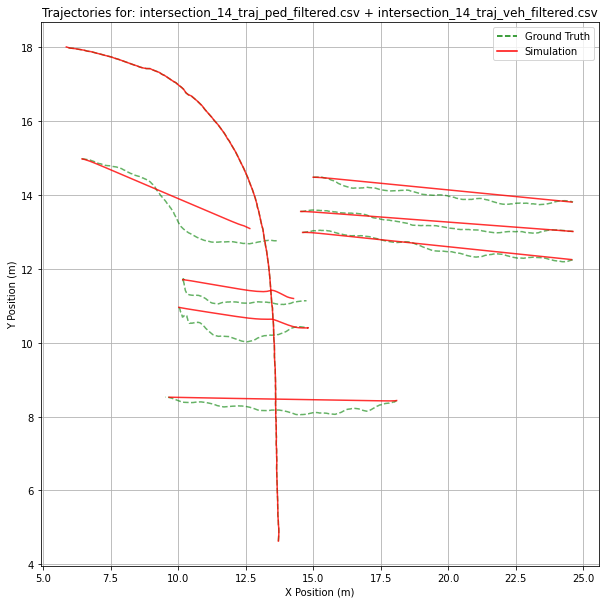

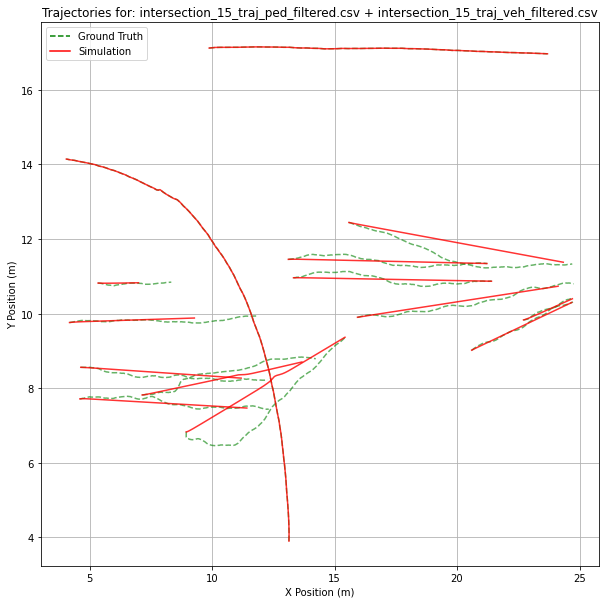

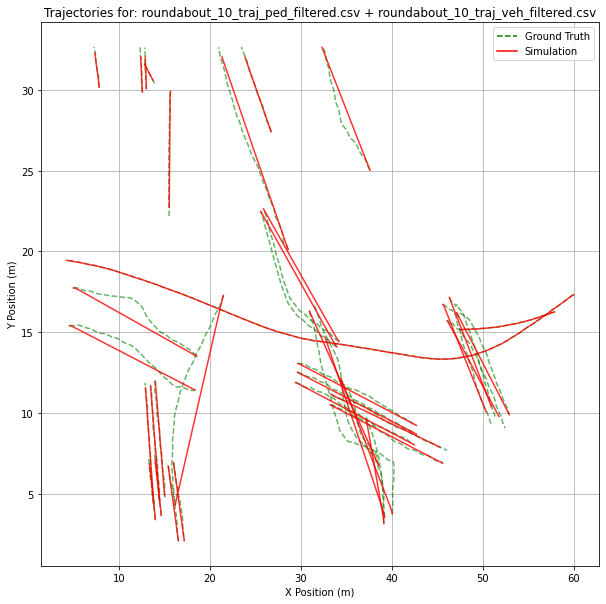

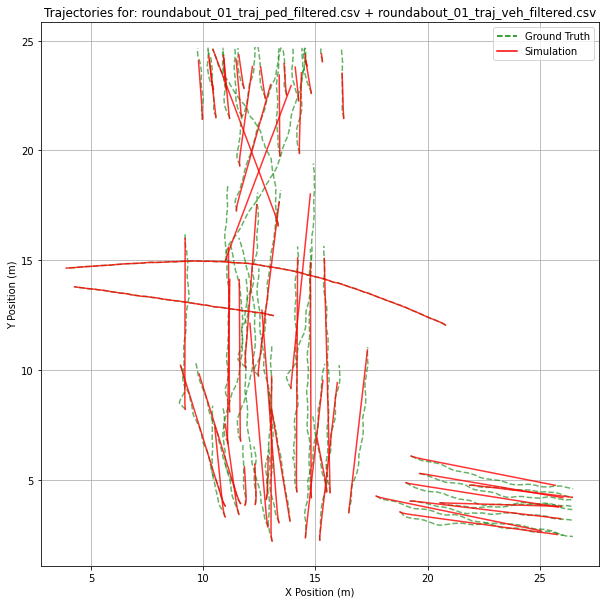

In [2]:
#轨迹绘制 campus
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from GSFM64 import GSFM
from SFM import SFM

# 配置路径和模型
data_dir = r"E:\BJTU-Thesis\data\campus_field_test"
model = GSFM(params={'ped_ped_strength_repul': 10.6, 'ped_ped_strength_navig': 1.4, 'des_strength': 7.8, 'ped_veh_strength': 10.9, 'ped_veh_decay': 1.4, 'crowd_range_fo': 2.6, 'TTC_threshold': 2.4, 'spd_yield_sigma': 0.4, 'GT_weight': 0.7, 'ped_single_alpha': 1.0, 'ped_group_alpha': 1.0, 'ped_ped_range_repul': 1.5, 'ped_ped_range_navig': 3.0, 'ped_des_speed': 2.0, 'destination_sigma': 0.8, 'anisotropy_lambda_p2v': 0.3})

             
all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []
ped_only = False

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))


# 遍历每一个场景文件对并绘图
for ped_file, veh_file in scenario_files:
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None
    
    try:
        ped_truth, veh_truth = model.load_data(ped_path, veh_path)
        ped_smlt, veh_smlt = model.simulate(ped_path, veh_path)
    except Exception as e:
        print(f"Error in {ped_file} + {veh_file}: {e}")
        continue

    plt.figure(figsize=(10, 10))

    # 真实轨迹 (绿色虚线)
    for _, grp in ped_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)
    for _, grp in veh_truth.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.6)

    # 模拟轨迹 (红色实线)
    for traj in ped_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)
    for traj in veh_smlt.values():
        xs = [s['x'] for s in traj]
        ys = [s['y'] for s in traj]
        plt.plot(xs, ys, '-', color='red', alpha=0.8)

    # 图示信息
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'Trajectories for: {ped_file} + {veh_file}')
    plt.legend(handles=[
        Line2D([0], [0], color='green', linestyle='--', label='Ground Truth'),
        Line2D([0], [0], color='red',   linestyle='-',  label='Simulation')
    ])
    plt.grid(True)
    plt.show()


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from GSFM import GSFM 
import pandas as pd

data_dir = r"E:\BJTU-Thesis\data\campus_field_test"
output_dir = r"E:\BJTU-Thesis\videos"
os.makedirs(output_dir, exist_ok=True)

model = GSFM(params={'tau': 1.7, 'ped_ped_strength_repul': 16.3, 'ped_ped_range_repul': 0.8, 'ped_ped_strength_navig': 13.9, 'ped_ped_range_navig': 0.7, 'ped_des_speed': 1.8, 'destination_sigma': 1.8, 'des_strength': 6.3, 'ped_veh_strength': 14.4, 'ped_veh_decay': 0.3, 'anisotropy_lambda_p2v': 0.9, 'ped_single_alpha': 0.7})

# upload data
all_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
scenario_files = []

if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split("_traj_")[0]
        scenario_dict.setdefault(key, {})
        if "_ped_" in f:
            scenario_dict[key]['ped'] = f
        elif "_veh_" in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))

# ======== 为每个场景生成视频 ========
for ped_file, veh_file in scenario_files:
    print(f"Processing: {ped_file}")
    ped_path = os.path.join(data_dir, ped_file)
    veh_path = os.path.join(data_dir, veh_file) if veh_file else None

    try:
        ped_truth, veh_truth = model.load_data(ped_path, veh_path)
        ped_smlt, veh_smlt = model.simulate(ped_path, veh_path)
    except Exception as e:
        print(f"Error in {ped_file}: {e}")
        continue

    all_frames = sorted(ped_truth['frame'].unique())
    x_min, x_max = min(ped_truth['x'].min() - 3, veh_truth['x'].min() - 3), max(ped_truth['x'].max() + 3, veh_truth['x'].max() + 3)
    y_min, y_max = min(ped_truth['y'].min() - 3, veh_truth['y'].min() - 3), max(ped_truth['y'].max() + 3, veh_truth['y'].max() + 3)

    # 存储帧图像
    frames = []

    for frame in all_frames:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{ped_file} - Frame {frame}")
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")


        # Ground Truth Pedestrian Trajectories (绿色虚线)
        for _, group in ped_truth.groupby('id'):
            past = group[group['frame'] <= frame]
            ax.plot(past['x'], past['y'], '--', color='green', alpha=0.6)

        # Simulated Pedestrian Trajectories
        for pid, traj in ped_smlt.items():
            past_points = [p for p in traj if p['frame'] <= frame]
            if not past_points:
                continue
            xs = [p['x'] for p in past_points]
            ys = [p['y'] for p in past_points]
            ax.plot(xs, ys, '-', color='red', alpha=0.8)
            ax.plot(xs[-1], ys[-1], 'o', color='red')

        # Vehicle Trajectories
        if veh_file and veh_truth is not None:
            for _, group in veh_truth.groupby('id'):
                past = group[group['frame'] <= frame]
                if past.empty:
                    continue
                xs = past['x'].tolist()
                ys = past['y'].tolist()
                ax.plot(xs, ys, '-', color='blue', alpha=0.8)
                ax.plot(xs[-1], ys[-1], 'o', color='blue')

        ax.legend(
            handles=[
                Line2D([0], [0], color='green', linestyle='--', label='Ped GT'),
                Line2D([0], [0], color='red', linestyle='-', label='Ped Sim'),
                Line2D([0], [0], color='blue', linestyle='-', label='Vehicle')
            ],
            bbox_to_anchor=(1.05, 1.0),
            borderaxespad=0.
        )
        ax.grid(True)

        # 保存帧图
        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(img)
        plt.close(fig)

    # 视频保存路径
    video_path = os.path.join(output_dir, ped_file.replace(".csv", "_trajectory_SFM.avi"))

    # 设置视频参数：fps=30, 分辨率
    height, width, _ = frames[0].shape
    writer = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'XVID'), 30, (width, height))

    for frame in frames:
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    writer.release()
    print(f"保存完成：{video_path}")


Processing: intersection_01_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\intersection_01_traj_ped_filtered_trajectory_SFM.avi
Processing: intersection_02_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\intersection_02_traj_ped_filtered_trajectory_SFM.avi
Processing: intersection_14_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\intersection_14_traj_ped_filtered_trajectory_SFM.avi
Processing: intersection_15_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\intersection_15_traj_ped_filtered_trajectory_SFM.avi
Processing: roundabout_10_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\roundabout_10_traj_ped_filtered_trajectory_SFM.avi
Processing: roundabout_01_traj_ped_filtered.csv
保存完成：E:\BJTU-Thesis\videos\roundabout_01_traj_ped_filtered_trajectory_SFM.avi


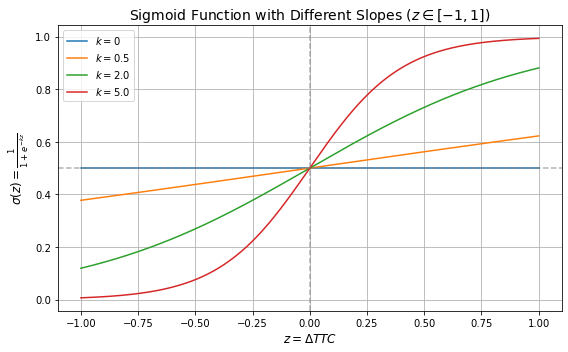

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z, k=1.0):
    return 1 / (1 + np.exp(-k * z))

# Define z range and different slope parameters
z = np.linspace(-1, 1, 500)
k_values = [0, 0.5, 2.0, 5.0]

# Plot setup
plt.figure(figsize=(8, 5))
for k in k_values:
    plt.plot(z, sigmoid(z, k), label=f'$k = {k}$')

# Labels and formatting
plt.title('Sigmoid Function with Different Slopes ($z \\in [-1, 1]$)', fontsize=14)
plt.xlabel('$z = \\Delta TTC$', fontsize=12)
plt.ylabel('$\\sigma(z) = \\frac{1}{1 + e^{-kz}}$', fontsize=12)
plt.grid(True)
plt.legend()
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.6)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save to PNG
plt.savefig('sigmoid_ttc_comparison_en.png', dpi=300)
plt.show()
